In [ ]:
# All paths in this notebook are relative to the repository root; anchor the working directory there
import os
while not os.path.exists('METHODOLOGY.md') and os.getcwd() != '/': os.chdir('..')
assert os.path.exists('METHODOLOGY.md'), 'run from inside the Nofit_LRT_Extension repository'

# PCA — Eigenvector Charts: where each component fits on the map

Companion to `THS_2018_MTX_PCA_vs_cellular.ipynb` (and its 2017 re-run). Those notebooks establish *that* the survey and cellular matrices share their dominant destination-choice patterns (subspace overlap 0.76, Tucker congruences 0.95 / 0.89 for the leading pair) but chart the eigenvectors only as two bar rows. This notebook draws the eigenvectors themselves — as **destination maps**, **origin-score maps**, ranked loading bars, biplots and a reconstruction check — so each component can be read as a spatial pattern and its fit judged by eye.

**Reading guide.** Each origin superzone is an observation; its row-normalized destination-share profile (36 shares) is the feature vector.

- an **eigenvector (loading vector)** is a direction in *destination* space: a signed weight per destination superzone → drawn as a map of destinations;
- an **origin score** is how strongly each origin's profile projects on that direction → drawn as a map of origins;
- an origin's profile ≈ mean profile + Σ score × eigenvector, so the two maps read together as "origins coloured *red* on the score map send more trips to destinations coloured *red* on the loading map (and fewer to the *blue* ones) than the average origin".

Components are matched across sources with the same Hungarian-matched Tucker congruence as the parent notebook, and the survey eigenvector is sign-aligned to its cellular partner (an eigenvector's sign is arbitrary). Survey **day 20** is charted next to day 10 as the noise benchmark: differences between the two survey days are what sampling noise alone does to an eigenvector.

**Inputs.** Superzone probability matrices `Output/historical/ths2018/prob_sz_cellular.csv`, `prob_sz_10_weighted.csv`, `prob_sz_20_weighted.csv`; the 2017 trips-file day-average `Output/ths2017/study_taz/matrix_avg_ALL_sznew.csv` (robustness row); polygons `Input/TAZ_North/TAZ_North.shp`, whose `SUPERZONE` field is the 36-zone `SZ_NEW` system.

In [1]:
import os
import numpy as np
import pandas as pd
import shapefile
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.collections import PolyCollection
from matplotlib.patches import Rectangle
from scipy.optimize import linear_sum_assignment

# palette (repo convention: blue = Day 10, orange = Day 20; aqua = cellular)
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, INK2, MUTED, GRID, AXIS = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
CMAP_DIV = LinearSegmentedColormap.from_list(
    'div_blue_red', ['#0d366b', '#2a78d6', '#86b6ef', '#f0efec', '#f2a29e', '#e34948', '#7f1e1e'])

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.grid(True, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    for s in ax.spines.values():
        s.set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=9)
    if title: ax.set_title(title, color=INK, fontsize=11)
    if xlabel: ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    if ylabel: ax.set_ylabel(ylabel, color=INK2, fontsize=10)

os.makedirs('Output/figures', exist_ok=True)
def save_show(fig, name):
    fig.savefig(f'Output/figures/{name}', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

## 1. Data — matrices and superzone geography

The superzone matrices are already row-normalized. The polygons come from the study TAZ shapefile; each TAZ ring is drawn in its superzone's colour, and superzone labels sit at the area-weighted centroid of the superzone's TAZs. The Haifa-bay superzones (5–18) are too small to read at study-area scale, so every map carries a zoom inset of the metro core.

In [2]:
def load_prob(path):
    m = pd.read_csv(path, index_col=0)
    m.index, m.columns = m.index.astype(int), m.columns.astype(int)
    return m

sz_cell = load_prob('Output/historical/ths2018/prob_sz_cellular.csv')
sz_s10 = load_prob('Output/historical/ths2018/prob_sz_10_weighted.csv')
sz_s20 = load_prob('Output/historical/ths2018/prob_sz_20_weighted.csv')
sz_17 = load_prob('Output/ths2017/study_taz/matrix_avg_ALL_sznew.csv')
sz_17 = sz_17.div(sz_17.sum(axis=1), axis=0)          # counts -> row probabilities
for m in (sz_s10, sz_s20, sz_17):
    assert list(m.index) == list(sz_cell.index) and list(m.columns) == list(sz_cell.columns)
    assert np.allclose(m.sum(axis=1), 1)
SZ = sz_cell.index.to_numpy()
n = len(SZ)

# --- geography: TAZ rings tagged with their superzone, area-weighted superzone centroids
sf = shapefile.Reader('Input/TAZ_North/TAZ_North.shp')
fld = [f[0] for f in sf.fields[1:]]

def ring_area_centroid(pts):
    x, y = pts[:, 0], pts[:, 1]
    cross = x * np.roll(y, -1) - np.roll(x, -1) * y
    a = 0.5 * cross.sum()
    if abs(a) < 1e-9:
        return 0.0, pts.mean(axis=0)
    return abs(a), np.array([((x + np.roll(x, -1)) * cross).sum(), ((y + np.roll(y, -1)) * cross).sum()]) / (6 * a)

rings, ring_sz, cent_rows = [], [], []
for sr in sf.shapeRecords():
    rec = dict(zip(fld, sr.record))
    pts = np.array(sr.shape.points)
    parts = list(sr.shape.parts) + [len(pts)]
    for a, b in zip(parts[:-1], parts[1:]):
        ring = pts[a:b]
        rings.append(ring); ring_sz.append(rec['SUPERZONE'])
        area, c = ring_area_centroid(ring)
        cent_rows.append((rec['SUPERZONE'], area, c[0], c[1]))
ring_sz = np.array(ring_sz)
assert set(ring_sz) == set(SZ)
cdf = pd.DataFrame(cent_rows, columns=['sz', 'area', 'x', 'y'])
cent = (cdf.groupby('sz').apply(lambda g: pd.Series({'x': np.average(g.x, weights=g.area),
                                                     'y': np.average(g.y, weights=g.area)}))
        .reindex(SZ))

# zoom window for the Haifa metro core (superzones 5-18)
core = [z for z in SZ if 5 <= z <= 18]
core_pts = np.vstack([r for r, z in zip(rings, ring_sz) if z in core])
pad = 1500
ZOOM = (core_pts[:, 0].min() - pad, core_pts[:, 0].max() + pad, core_pts[:, 1].min() - pad, core_pts[:, 1].max() + pad)

def draw_map(ax, values, vmax, inset=True, labels=True):
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    v = pd.Series(np.asarray(values, float), index=SZ)
    colors = CMAP_DIV(norm(v.reindex(ring_sz).values))
    ax.add_collection(PolyCollection(rings, facecolors=colors, edgecolors=colors, linewidths=0.3))
    ax.autoscale(); ax.set_aspect('equal'); ax.axis('off')
    if labels:
        for z in SZ:
            if z not in core:
                ax.text(cent.x[z], cent.y[z], str(z), ha='center', va='center', fontsize=6.5, color=INK2)
    if inset:
        ax.add_patch(Rectangle((ZOOM[0], ZOOM[2]), ZOOM[1] - ZOOM[0], ZOOM[3] - ZOOM[2],
                               fill=False, edgecolor=INK2, linewidth=0.6))
        ia = ax.inset_axes([0.0, 0.68, 0.40, 0.32])
        ia.add_collection(PolyCollection(rings, facecolors=colors, edgecolors='white', linewidths=0.25))
        ia.set_xlim(ZOOM[0], ZOOM[1]); ia.set_ylim(ZOOM[2], ZOOM[3]); ia.set_aspect('equal')
        ia.set_xticks([]); ia.set_yticks([])
        for s in ia.spines.values():
            s.set_color(INK2); s.set_linewidth(0.6)
        for z in core:
            ia.text(cent.x[z], cent.y[z], str(z), ha='center', va='center', fontsize=5.5, color=INK)

print(f"{n} superzones, {len(rings)} TAZ rings; metro-core inset covers superzones {core[0]}–{core[-1]}")

36 superzones, 788 TAZ rings; metro-core inset covers superzones 5–18


**Superzone key.** The superzones are numbered, not named; the table below gives each one a reading aid — its dominant sub-district (from `Input/Demographic_Forecast/TAZ_shp`, joined by TAZ) and, inside the LRT corridor, the research-area names of `Input/Submatrix_tazs.xlsx`.

In [3]:
sf2 = shapefile.Reader('Input/Demographic_Forecast/TAZ_shp/TAZ North.shp', encoding='utf-8')
nafa = pd.DataFrame(sf2.records(), columns=[f[0] for f in sf2.fields[1:]])[['TAZ_NUMBER', 'NAFA']]
taz_sz = pd.DataFrame(sf.records(), columns=fld)[['TAZ_NUMBER', 'SUPERZONE']]
EN = {'חיפה': 'Haifa', 'עכו': 'Akko', 'יזרעאל': "Yizre'el", 'חדרה': 'Hadera', 'כנרת': 'Kinneret',
      'צפת': 'Tzfat', 'רמת הגולן': 'Golan'}
sub = pd.read_excel('Input/Submatrix_tazs.xlsx').merge(taz_sz, left_on='TAZ', right_on='TAZ_NUMBER')
key = (taz_sz.merge(nafa, on='TAZ_NUMBER', how='left')
       .assign(NAFA=lambda d: d.NAFA.map(EN))
       .groupby('SUPERZONE').agg(n_TAZ=('TAZ_NUMBER', 'size'),
                                 sub_district=('NAFA', lambda s: s.mode().iloc[0] if s.notna().any() else ''))
       .join(sub.groupby('SUPERZONE')['AggAreaName']
             .agg(lambda s: ', '.join(s.value_counts().index[:3])).rename('corridor_areas'))
       .fillna({'corridor_areas': ''}).reindex(SZ))
key.index.name = 'SZ'
SZ_KEY = key
pd.set_option('display.width', 160)
key

,n_TAZ,sub_district,corridor_areas
SZ,,,
1,18,Akko,
2,45,Akko,
3,38,Akko,
4,23,Akko,Shefaram
5,14,Haifa,Kiryat Yam
6,13,Haifa,Kiryat Motzkin-Bialik
7,27,Haifa,"Kiryat Motzkin-Bialik, Kiryat Ata Center, Kiry..."
8,9,Haifa,"Kiryat Motzkin-Bialik, Kiryat Yam"
9,25,Haifa,"Kiryat Ata East, Kiryat Ata South, Kiryat Ata ..."


## 2. PCA and component matching

Same PCA as the parent notebook (column-centred SVD of the origin × destination probability matrix, eigenvectors in destination space). Components of each survey matrix are matched one-to-one to cellular's top 6 by Hungarian assignment on |Tucker congruence|, and sign-aligned so that a matched pair points the same way.

In [4]:
def pca(P):
    X = np.asarray(P, dtype=float)
    Xc = X - X.mean(axis=0)
    U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
    lam = s ** 2 / (X.shape[0] - 1)
    return {'V': Vt.T, 'lam': lam, 'evr': lam / lam.sum(), 'scores': U * s, 'mean': X.mean(axis=0)}

P = {'cellular': sz_cell, 'survey d10': sz_s10, 'survey d20': sz_s20, 'survey 2017': sz_17}
PC = {name: pca(m) for name, m in P.items()}

KC = 6
def match_to_cellular(name):
    # returns {cellular j: (survey i, signed congruence)} over the top-KC components
    C = PC[name]['V'][:, :KC].T @ PC['cellular']['V'][:, :KC]
    ri, ci = linear_sum_assignment(-np.abs(C))
    return {j: (i, C[i, j]) for i, j in zip(ri, ci)}

MATCH = {name: match_to_cellular(name) for name in ['survey d10', 'survey d20', 'survey 2017']}

def aligned(name, j):
    # survey eigenvector / scores matched to cellular PC j, sign-aligned to it
    if name == 'cellular':
        return j, 1.0, PC[name]['V'][:, j], PC[name]['scores'][:, j]
    i, c = MATCH[name][j]
    sgn = np.sign(c)
    return i, abs(c), sgn * PC[name]['V'][:, i], sgn * PC[name]['scores'][:, i]

rows = []
for j in range(KC):
    row = {'cellular PC': j + 1, 'cellular var. share': PC['cellular']['evr'][j]}
    for name in MATCH:
        i, phi = MATCH[name][j]
        row[f'{name} PC'] = i + 1
        row[f'{name} |φ|'] = abs(phi)
    rows.append(row)
pd.DataFrame(rows).set_index('cellular PC').round(3)

,cellular var. share,survey d10 PC,survey d10 |φ|,survey d20 PC,survey d20 |φ|,survey 2017 PC,survey 2017 |φ|
cellular PC,,,,,,,
1,0.139,2,0.891,2,0.900,2,0.882
2,0.134,1,0.946,1,0.954,1,0.968
3,0.109,3,0.890,3,0.875,3,0.851
4,0.085,4,0.820,4,0.902,4,0.906
5,0.073,6,0.641,6,0.560,5,0.705
6,0.059,5,0.851,5,0.781,6,0.450


## 3. Eigenvectors as destination maps

Each column is one cellular component and the survey components matched to it (day 10, then day 20 as the noise benchmark). Red destinations carry positive loadings, blue negative; the colour scale is shared within a column so the survey and cellular eigenvectors are directly comparable. Variance share is each source's own.

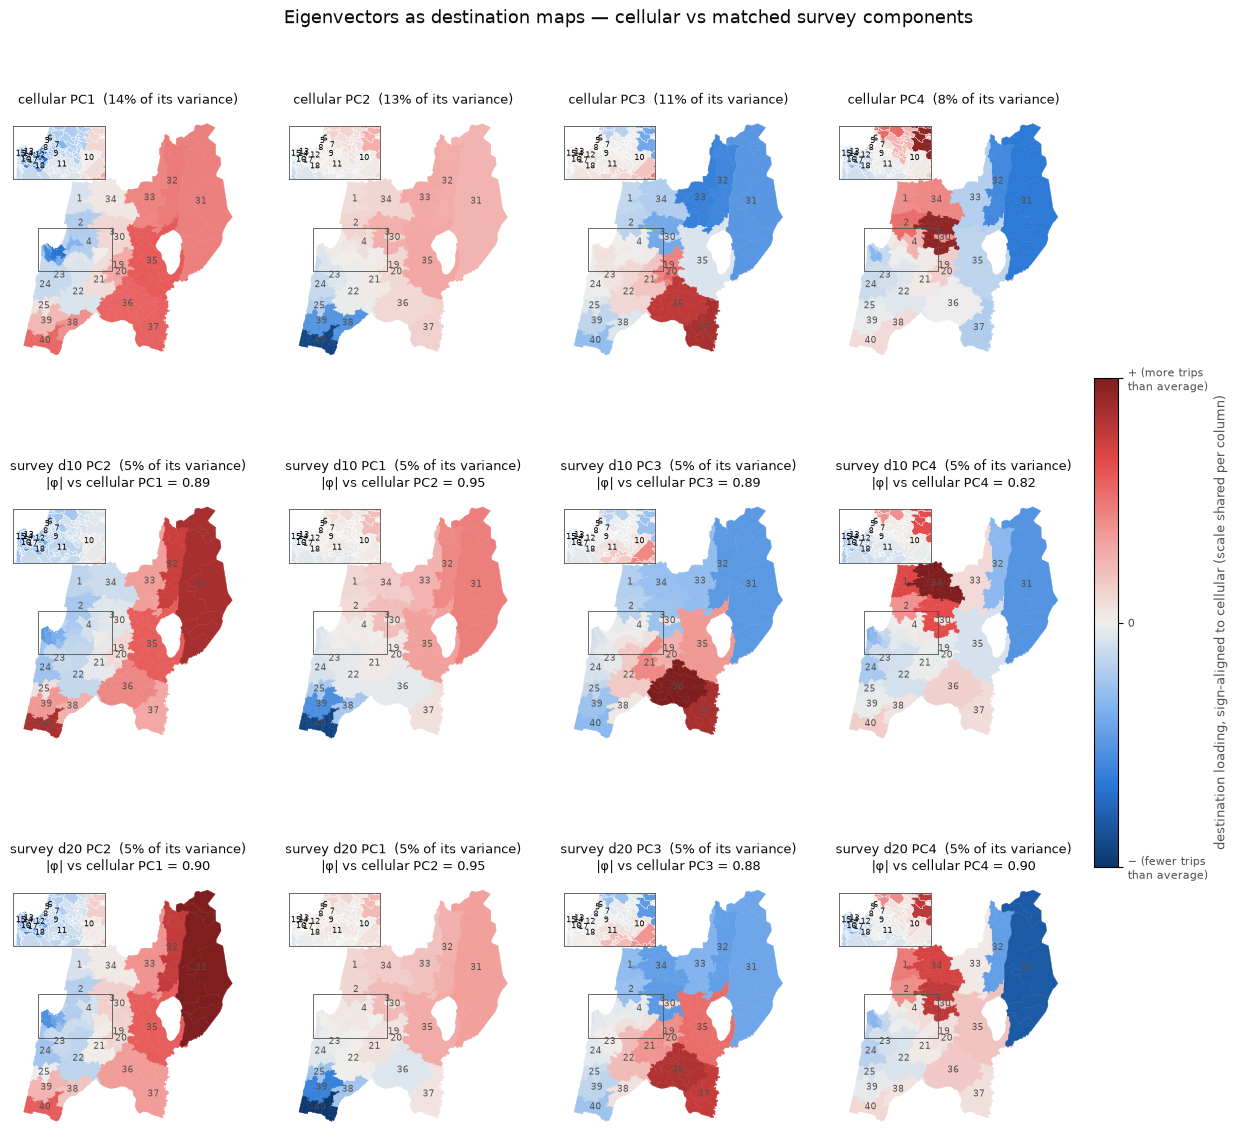

In [5]:
K = 4
SOURCES = ['cellular', 'survey d10', 'survey d20']
fig, axes = plt.subplots(len(SOURCES), K, figsize=(4.1 * K, 4.7 * len(SOURCES)), facecolor='white')
for j in range(K):
    vecs = {name: aligned(name, j) for name in SOURCES}
    vmax = max(np.abs(v[2]).max() for v in vecs.values())
    for r, name in enumerate(SOURCES):
        i, phi, V, _ = vecs[name]
        draw_map(axes[r, j], V, vmax)
        title = f"{name} PC{i+1}  ({PC[name]['evr'][i]:.0%} of its variance)"
        if name != 'cellular':
            title += f"\n|φ| vs cellular PC{j+1} = {phi:.2f}"
        axes[r, j].set_title(title, color=INK, fontsize=9.5)
sm = plt.cm.ScalarMappable(cmap=CMAP_DIV, norm=TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1))
cb = fig.colorbar(sm, ax=axes, shrink=0.45, pad=0.02, ticks=[-1, 0, 1])
cb.ax.set_yticklabels(['− (fewer trips\nthan average)', '0', '+ (more trips\nthan average)'], fontsize=8, color=INK2)
cb.set_label('destination loading, sign-aligned to cellular (scale shared per column)', color=INK2, fontsize=9)
fig.suptitle('Eigenvectors as destination maps — cellular vs matched survey components', color=INK, fontsize=13, y=0.93)
save_show(fig, 'pca_eigenvector_maps.png')

## 4. Loadings ranked — the same eigenvectors as sorted bars

The maps show *where*; the bars show *how much* and make the small Haifa-bay superzones legible. Destinations are ordered by the cellular loading, with the sign-aligned survey (day 10) loading alongside.

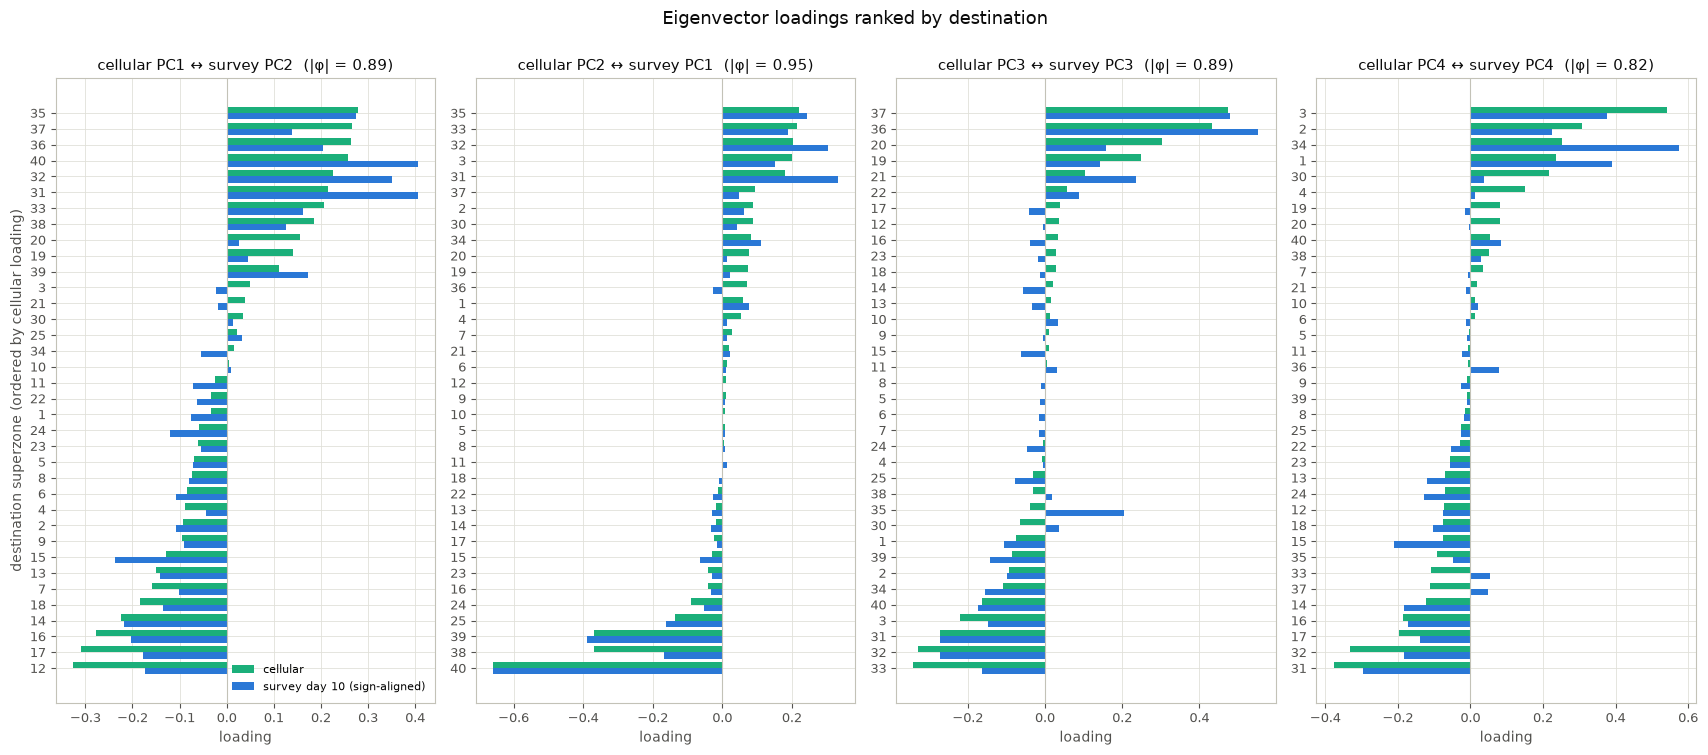

In [6]:
fig, axes = plt.subplots(1, K, figsize=(4.3 * K, 7.5), facecolor='white')
y = np.arange(n)
for j, ax in enumerate(axes):
    _, _, vc, _ = aligned('cellular', j)
    i, phi, vs, _ = aligned('survey d10', j)
    order = np.argsort(vc)
    ax.barh(y + 0.2, vc[order], height=0.4, color=AQUA, label='cellular')
    ax.barh(y - 0.2, vs[order], height=0.4, color=BLUE, label='survey day 10 (sign-aligned)')
    ax.set_yticks(y, SZ[order], fontsize=7)
    ax.axvline(0, color=AXIS, linewidth=0.8)
    style_ax(ax, f'cellular PC{j+1} ↔ survey PC{i+1}  (|φ| = {phi:.2f})', 'loading',
             'destination superzone (ordered by cellular loading)' if j == 0 else None)
    if j == 0:
        ax.legend(frameon=False, fontsize=8, loc='lower right')
fig.suptitle('Eigenvector loadings ranked by destination', color=INK, fontsize=13, y=1.0)
plt.tight_layout()
save_show(fig, 'pca_eigenvector_loadings_ranked.png')

## 5. Origin scores — which origins express each pattern

The score map is the other half of the eigenvector: an origin coloured red projects positively on the component, i.e. its destination profile leans toward the red destinations of the corresponding loading map. Together the two maps read as the spatial "pattern" the component encodes.

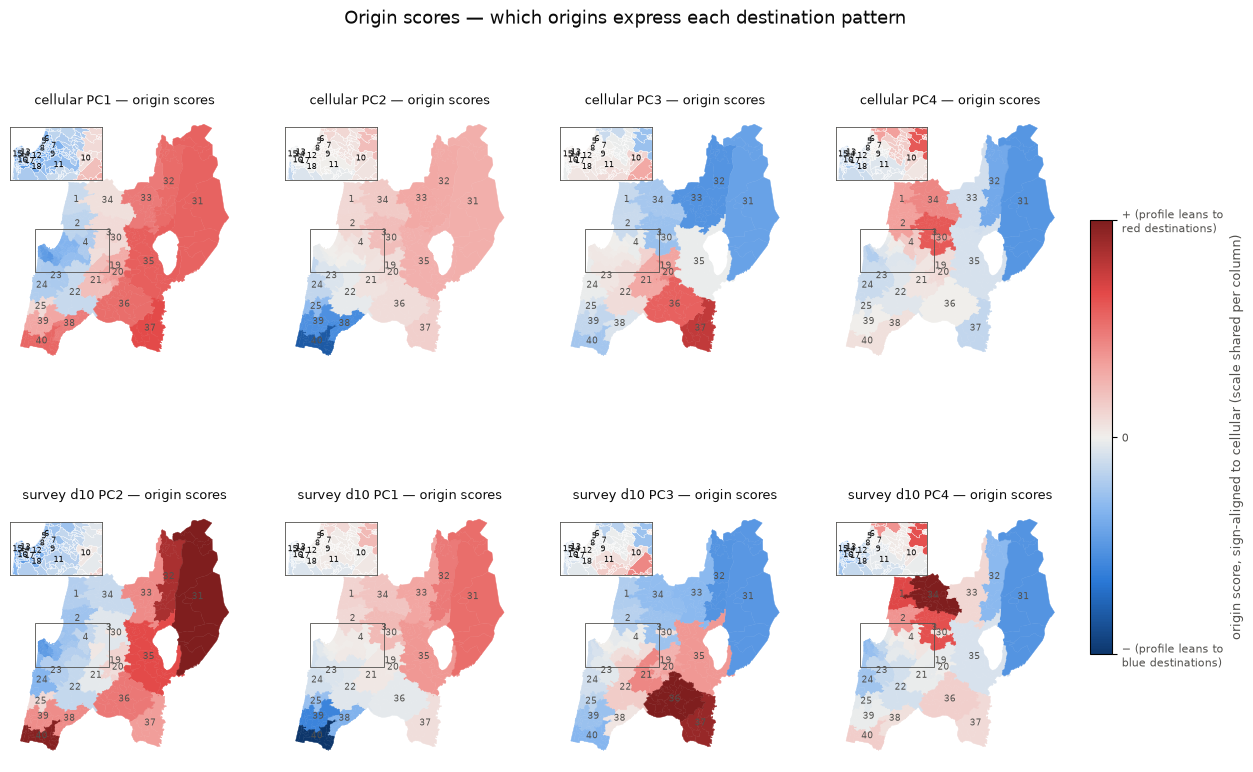

In [7]:
SC_SOURCES = ['cellular', 'survey d10']
fig, axes = plt.subplots(len(SC_SOURCES), K, figsize=(4.1 * K, 4.7 * len(SC_SOURCES)), facecolor='white')
for j in range(K):
    vecs = {name: aligned(name, j) for name in SC_SOURCES}
    vmax = max(np.abs(v[3]).max() for v in vecs.values())
    for r, name in enumerate(SC_SOURCES):
        i, phi, _, S = vecs[name]
        draw_map(axes[r, j], S, vmax)
        axes[r, j].set_title(f'{name} PC{i+1} — origin scores', color=INK, fontsize=9.5)
sm = plt.cm.ScalarMappable(cmap=CMAP_DIV, norm=TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1))
cb = fig.colorbar(sm, ax=axes, shrink=0.6, pad=0.02, ticks=[-1, 0, 1])
cb.ax.set_yticklabels(['− (profile leans to\nblue destinations)', '0', '+ (profile leans to\nred destinations)'],
                      fontsize=8, color=INK2)
cb.set_label('origin score, sign-aligned to cellular (scale shared per column)', color=INK2, fontsize=9)
fig.suptitle('Origin scores — which origins express each destination pattern', color=INK, fontsize=13, y=0.95)
save_show(fig, 'pca_eigenvector_scores.png')

## 6. Biplots — origins and destinations on the leading two components

Dots are origins (scores on PC1 and PC2); arrows are the destinations with the largest loadings on that plane, scaled to fit. An origin lies in the direction of the destinations it favours. In cellular the axes are the leading two of *its* PCA; in the survey they are its own PC1 / PC2 — the same two patterns in swapped order, so the survey panel appears rotated by about 90° relative to cellular.

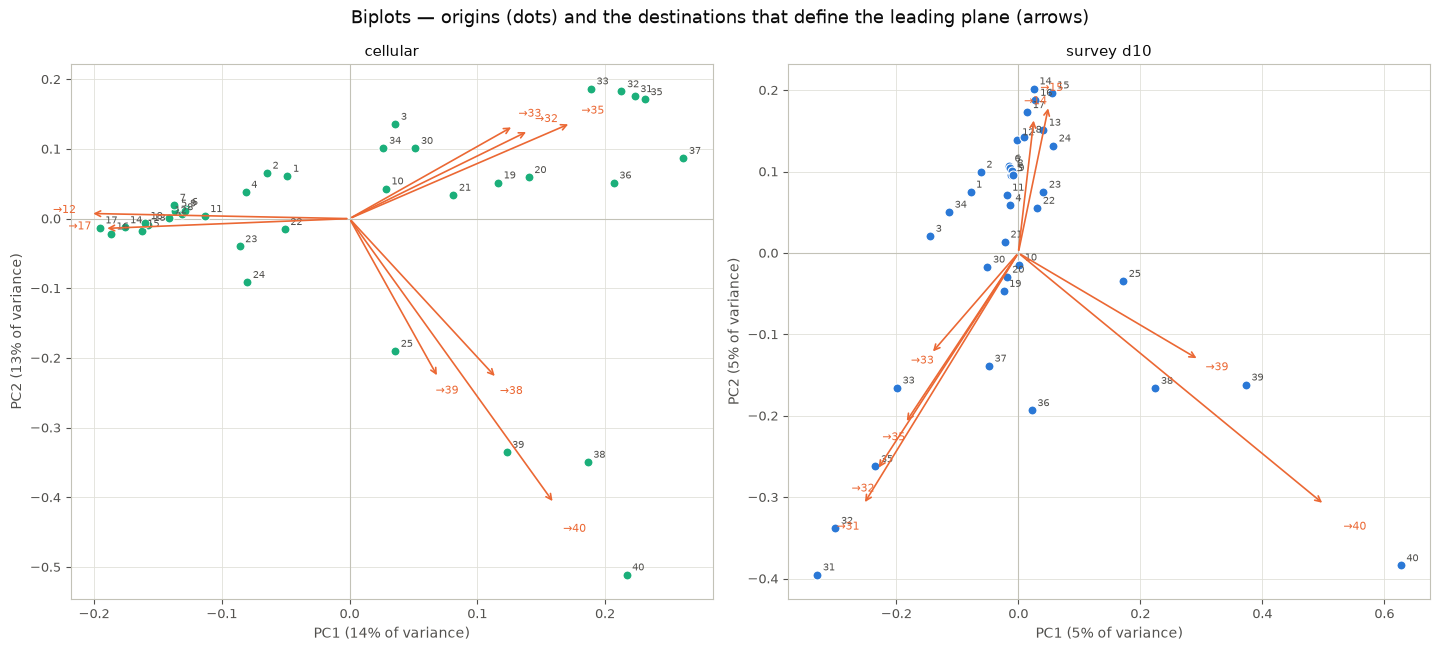

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.6), facecolor='white')
for ax, name, col in zip(axes, ['cellular', 'survey d10'], [AQUA, BLUE]):
    pc = PC[name]
    sc, V = pc['scores'][:, :2], pc['V'][:, :2]
    scale = 0.8 * np.abs(sc).max() / np.abs(V).max()
    ax.scatter(sc[:, 0], sc[:, 1], s=42, color=col, edgecolors='white', linewidths=0.8, zorder=3)
    for k in range(n):
        ax.annotate(str(SZ[k]), sc[k], textcoords='offset points', xytext=(4, 3), fontsize=7, color=INK2)
    top = np.argsort(-np.hypot(V[:, 0], V[:, 1]))[:8]
    for k in top:
        ax.annotate('', xy=V[k] * scale, xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.2))
        ax.text(V[k, 0] * scale * 1.1, V[k, 1] * scale * 1.1, f'→{SZ[k]}', color=ORANGE, fontsize=8, ha='center')
    ax.axhline(0, color=AXIS, lw=0.8); ax.axvline(0, color=AXIS, lw=0.8)
    style_ax(ax, name, f"PC1 ({pc['evr'][0]:.0%} of variance)", f"PC2 ({pc['evr'][1]:.0%} of variance)")
fig.suptitle('Biplots — origins (dots) and the destinations that define the leading plane (arrows)',
             color=INK, fontsize=13)
plt.tight_layout()
save_show(fig, 'pca_eigenvector_biplot.png')

## 7. What the axes mean — three checks on the cellular eigenvectors

1. PC1's origin score against the origin's self-containment (share of trips staying inside the superzone) — the parent notebook's reading of PC1 as the self-containment axis;
2. PC1's *loading* against the destination's mean share across origins — does PC1 simply separate the big attractors from the rest?
3. PC2's loading against the superzone's northing — the north–south reading.

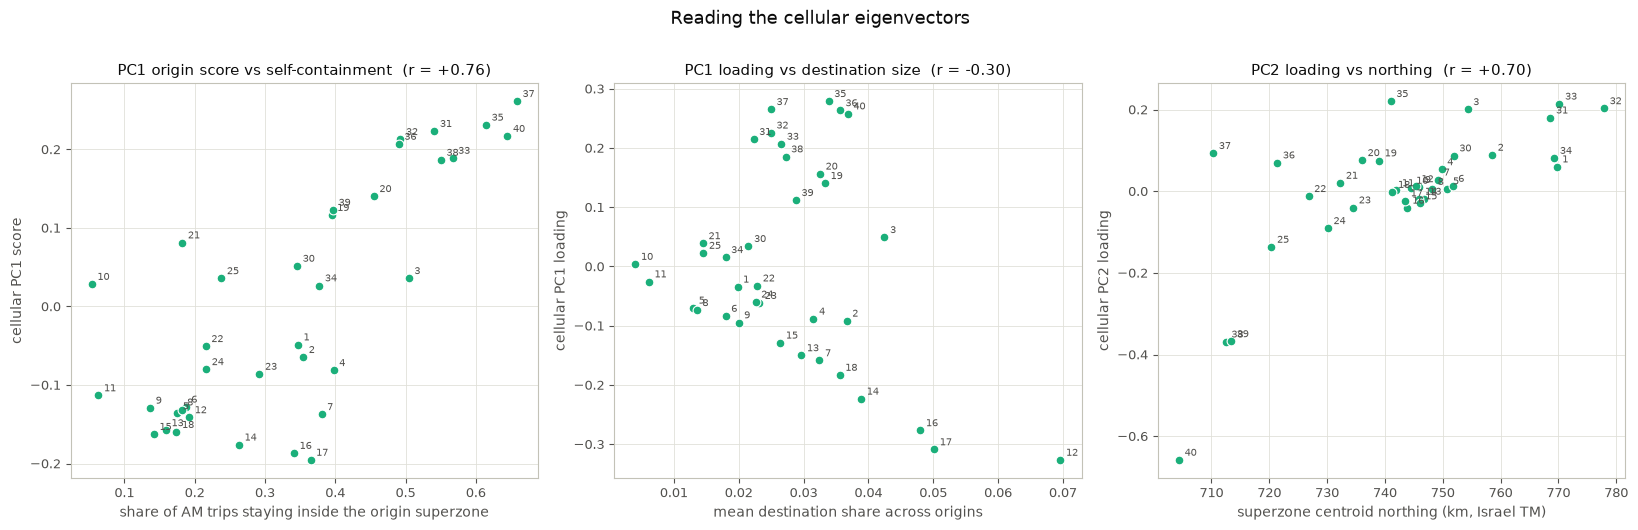

survey d10 (matched): score vs self-containment r = +0.76; loading vs northing r = +0.74


In [9]:
pc = PC['cellular']
selfc = np.diag(sz_cell.values)
northing = cent.y.values / 1000

def labelled_scatter(ax, x, yv, title, xlabel, ylabel):
    ax.scatter(x, yv, s=40, color=AQUA, edgecolors='white', linewidths=0.8, zorder=3)
    for k in range(n):
        ax.annotate(str(SZ[k]), (x[k], yv[k]), textcoords='offset points', xytext=(4, 3), fontsize=7, color=INK2)
    r = np.corrcoef(x, yv)[0, 1]
    style_ax(ax, f'{title}  (r = {r:+.2f})', xlabel, ylabel)
    return r

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2), facecolor='white')
r1 = labelled_scatter(axes[0], selfc, pc['scores'][:, 0], 'PC1 origin score vs self-containment',
                      'share of AM trips staying inside the origin superzone', 'cellular PC1 score')
r2 = labelled_scatter(axes[1], pc['mean'], pc['V'][:, 0], 'PC1 loading vs destination size',
                      'mean destination share across origins', 'cellular PC1 loading')
r3 = labelled_scatter(axes[2], northing, pc['V'][:, 1], 'PC2 loading vs northing',
                      'superzone centroid northing (km, Israel TM)', 'cellular PC2 loading')
fig.suptitle('Reading the cellular eigenvectors', color=INK, fontsize=13, y=1.01)
plt.tight_layout()
save_show(fig, 'pca_eigenvector_meaning.png')

print(f"survey d10 (matched): score vs self-containment r = "
      f"{np.corrcoef(np.diag(sz_s10.values), aligned('survey d10', 0)[3])[0, 1]:+.2f}; "
      f"loading vs northing r = {np.corrcoef(northing, aligned('survey d10', 1)[2])[0, 1]:+.2f}")

## 8. How the eigenvectors fit a profile

An origin's profile is rebuilt as *mean + Σ score × eigenvector* with 1, 2 and 4 components and laid over the observed profile, for the origins at the two ends of PC1. This is the "fit" check: how much of a real destination profile the leading eigenvectors reproduce, and what they leave behind. The panel below it summarizes the same thing for all origins — the median residual after k components, for cellular and for both survey days.

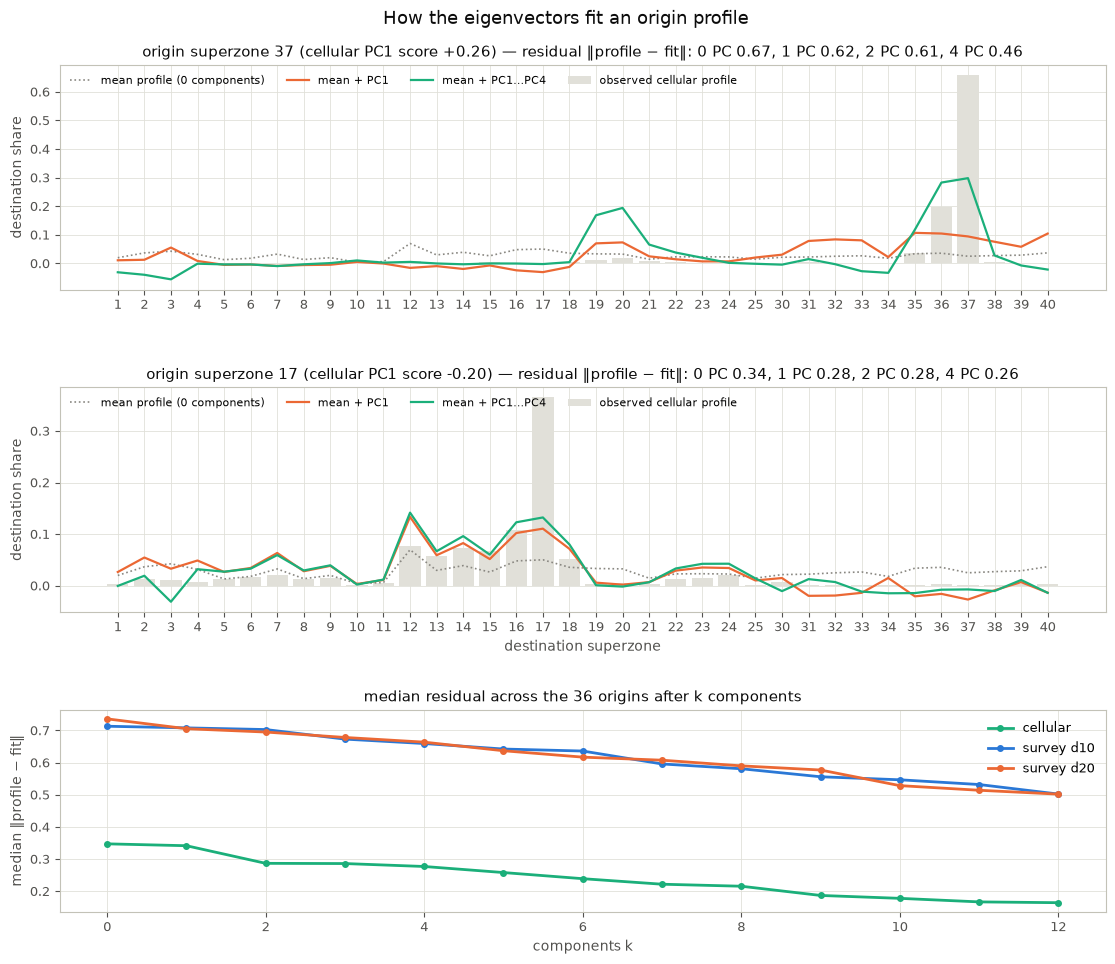

In [10]:
def recon(pc, i, k):
    return pc['mean'] + pc['scores'][i, :k] @ pc['V'][:, :k].T

pc, X = PC['cellular'], sz_cell.values
examples = [int(np.argmax(pc['scores'][:, 0])), int(np.argmin(pc['scores'][:, 0]))]
x = np.arange(n)

fig = plt.figure(figsize=(13.5, 11), facecolor='white')
gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 0.9], hspace=0.45)
for row, i in enumerate(examples):
    ax = fig.add_subplot(gs[row])
    ax.bar(x, X[i], color=GRID, width=0.8, label='observed cellular profile')
    ax.plot(x, pc['mean'], color=MUTED, lw=1.2, ls=':', label='mean profile (0 components)')
    ax.plot(x, recon(pc, i, 1), color=ORANGE, lw=1.6, label='mean + PC1')
    ax.plot(x, recon(pc, i, 4), color=AQUA, lw=1.6, label='mean + PC1…PC4')
    err = {k: np.linalg.norm(X[i] - recon(pc, i, k)) for k in (0, 1, 2, 4)}
    ax.set_xticks(x, SZ, fontsize=7)
    style_ax(ax, f"origin superzone {SZ[i]} (cellular PC1 score {pc['scores'][i, 0]:+.2f}) — "
                 f"residual ‖profile − fit‖: " + ', '.join(f'{k} PC {v:.2f}' for k, v in err.items()),
             'destination superzone' if row == 1 else None, 'destination share')
    ax.legend(frameon=False, fontsize=8, ncols=4, loc='upper left')

ax = fig.add_subplot(gs[2])
ks = np.arange(0, 13)
for name, col in [('cellular', AQUA), ('survey d10', BLUE), ('survey d20', ORANGE)]:
    pcn, Xn = PC[name], P[name].values
    med = [np.median([np.linalg.norm(Xn[i] - recon(pcn, i, k)) for i in range(n)]) for k in ks]
    ax.plot(ks, med, color=col, lw=2, marker='o', ms=4, label=name)
style_ax(ax, 'median residual across the 36 origins after k components', 'components k', 'median ‖profile − fit‖')
ax.legend(frameon=False, fontsize=9)
fig.suptitle('How the eigenvectors fit an origin profile', color=INK, fontsize=13, y=0.93)
save_show(fig, 'pca_eigenvector_fit.png')

## 9. Robustness — the 2017 trips-file survey

The pipeline's primary fusion source is the 2017 trips file (`THS_2017_PCA_vs_cellular.ipynb`). Its day-average superzone matrix is matched to the same cellular components; the trips file is the same household panel as the 2018 activities file, extracted through a different chain, so matching maps replicate the processing, not the sample. (The cellular matrix here is `Output/historical/ths2018/prob_sz_cellular.csv`; the 2017 notebook rebuilt its own with a slightly different TAZ→superzone key precedence, which moves a handful of cells by ≤ 0.07.)

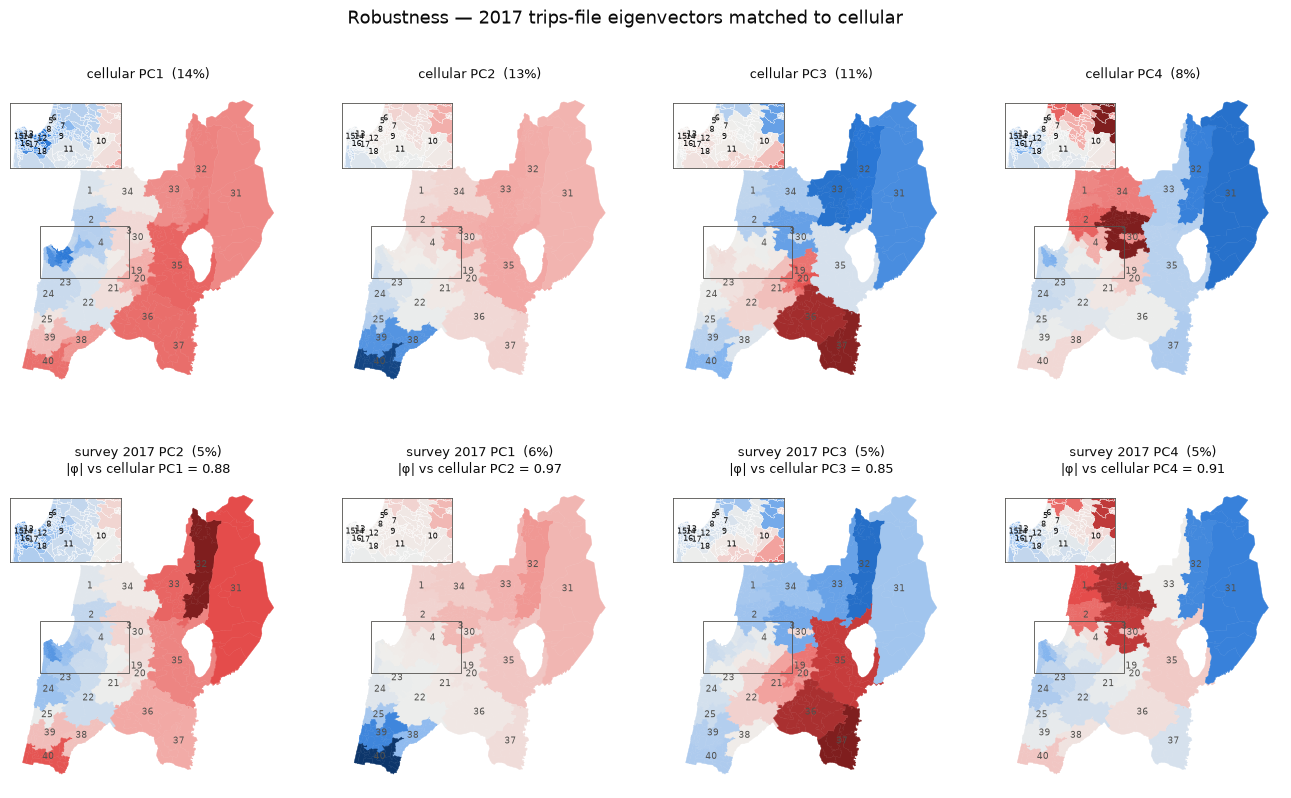

In [11]:
fig, axes = plt.subplots(2, K, figsize=(4.1 * K, 9.4), facecolor='white')
for j in range(K):
    vecs = {name: aligned(name, j) for name in ['cellular', 'survey 2017']}
    vmax = max(np.abs(v[2]).max() for v in vecs.values())
    for r, name in enumerate(['cellular', 'survey 2017']):
        i, phi, V, _ = vecs[name]
        draw_map(axes[r, j], V, vmax)
        title = f"{name} PC{i+1}  ({PC[name]['evr'][i]:.0%})"
        if name != 'cellular':
            title += f"\n|φ| vs cellular PC{j+1} = {phi:.2f}"
        axes[r, j].set_title(title, color=INK, fontsize=9.5)
fig.suptitle('Robustness — 2017 trips-file eigenvectors matched to cellular', color=INK, fontsize=13, y=0.95)
save_show(fig, 'pca_eigenvector_maps_2017.png')

## 10. Export

Long-format table of the top-6 eigenvectors and origin scores of every source, with the cellular match and the alignment sign applied, for use outside the notebook (`Output/historical/ths2018/pca_sz_eigenvectors.csv`).

In [12]:
out = []
for name in P:
    for j in range(KC):
        i, phi, V, S = aligned(name, j)
        for k in range(n):
            out.append({'source': name, 'own_pc': i + 1, 'matched_cellular_pc': j + 1,
                        'congruence': phi, 'var_share': PC[name]['evr'][i],
                        'superzone': int(SZ[k]), 'loading': V[k], 'origin_score': S[k]})
eig = pd.DataFrame(out)
eig.to_csv('Output/historical/ths2018/pca_sz_eigenvectors.csv', index=False)
print(eig.shape)
eig.head()

(864, 8)


,source,own_pc,matched_cellular_pc,congruence,var_share,superzone,loading,origin_score
0,cellular,1,1,1.0,0.13936,1,-0.034320,-0.048577
1,cellular,1,1,1.0,0.13936,2,-0.091744,-0.064614
2,cellular,1,1,1.0,0.13936,3,0.049261,0.035858
3,cellular,1,1,1.0,0.13936,4,-0.088355,-0.081295
4,cellular,1,1,1.0,0.13936,5,-0.069721,-0.136314


## 11. Findings

> **Revised after review** — see `THS_PCA_review_tests.ipynb` for the direct tests behind the revisions. Congruence bands follow Lorenzo-Seva & ten Berge (2006): |φ| ≥ 0.95 "equal", 0.85–0.94 "fair similarity".

**1. The four leading eigenvectors are four legible regional patterns, and related versions of each appear in both sources.** Read as destination maps (with the origin-score maps alongside):

| cellular PC | variance share (cellular / survey) | \|φ\| survey d10 / d20 / 2017 | pattern |
|---|---|---|---|
| PC1 | 14% / 5% | 0.89 / 0.90 / 0.88 | **Haifa core vs periphery.** Negative loadings on the metro core (12 Namal–Hamifrats, 17, 16, 14, 18, 7, 13, 15), positive on the Galilee, Golan, Kinneret, Yizre'el and Hadera superzones. Origins score positively when they are peripheral: their profiles lean toward their own region rather than the Haifa core, which is why the score tracks self-containment (r = +0.76). Fair similarity. |
| PC2 | 13% / 5% | 0.95 / 0.95 / 0.97 | **North–south.** Hadera-side destinations (40, 38, 39, 25) against the Galilee (35, 33, 32, 3, 31); loading vs northing r = +0.70. The only pair at the "equal" level. |
| PC3 | 11% / 5% | 0.89 / 0.88 / 0.85 | **Yizre'el / Nazareth vs Upper Galilee–Golan.** Positive on 37, 36, 20, 19, 21, 22; negative on 33, 32, 31 (and 3, 40). The survey attaches Kinneret (35) to the Yizre'el side (+0.20) where cellular does not (−0.05): a destination-loading difference, which shifts reconstructed flows to 35 from every origin that scores on PC3, not a single OD cell. |
| PC4 | 8% / 5% | 0.82 / 0.90 / 0.91 | **Western Galilee / Akko vs Golan.** Positive on 3, 2, 34, 1, 30; negative on 31, 32 and on the Haifa core (17, 16, 15). Fair similarity. |

The four components carry 46 % of cellular variance and 21 % of survey variance; their agreement describes the dominant patterns, not the bulk of either matrix. The parent notebook's "self-containment axis" is specifically *core-vs-periphery*: PC1's loading is only weakly related to destination size in general (r = −0.30) and singles out the Haifa metro attractors.

**2. The survey's eigenvectors are reproducible across its two days, and its eigenvalues are flattened by its diagonal.** Day 10 and day 20 give near-identical maps for PC1–PC4 (congruence with cellular within 0.01–0.08 of each other). The two days come from the same households, so this is a repeatability check under shared sampling and reporting biases, not independent evidence; the household bootstrap in the follow-up notebook puts the sampling spread at roughly ±0.1 on each congruence. The flat survey spectrum (≈ 5 % per component against 14 / 13 / 11 / 8 %) is produced by the survey's diagonal alone: cellular given the survey's self-shares, with no noise, has the same spectrum, while resampling cellular at the survey's sample sizes changes nothing. The first version of this notebook attributed the flattening to sampling noise; that was wrong.

**3. Where the eigenvectors fit and where they do not.** Rebuilding origin profiles from the leading components reproduces the *shape* of each profile — which region an origin favours — but not the diagonal spike: for superzone 37, four components rebuild 0.30 of an observed 0.66 self-share, and the median residual across cellular origins falls from 0.35 (mean only) to 0.28 with two components and 0.16 with twelve. Survey profiles start further from their mean (median residual 0.71) and stay above 0.50 even with twelve components because the survey diagonal (≈ 68–72 % self-containment) dominates every row. This is a property of the low-rank representation, not a test of where the sources disagree; that test (conditional outbound distributions) is in the follow-up notebook and finds outbound differences of about twice the day-to-day noise.

**4. The 2017 trips-file survey draws the same maps** (congruences 0.88 / 0.97 / 0.85 / 0.91 on PC1–PC4). It is the same household panel as the 2018 activities file, extracted through an independent processing chain, so this replicates the processing, not the sample.